# pyFDN parameter-spec FLAMO graphs

Every registered pyFDN parameter specification is sampled, converted into its complete `FlamoFDN`, compiled through `pyFDN.dss_to_flamo` via `to_flamo`, and drawn with `pyFDN.plot_flamo_graph`. Each sampled build is also visualized with `pyFDN.plot_fdn_parameter`, including its delay lengths, feedback matrix, input/output/direct matrices, and attenuation filters. The executed image outputs are committed so GitHub renders the verified graph inventory.


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image, Markdown, display
from pyFDN import plot_fdn_parameter, plot_flamo_graph

from synth_setter.data.pyfdn_param_spec import (
    FlamoFDNParamSpec,
    pyfdn_param_spec_sha256,
)
from synth_setter.data.vst.param_spec_registry import param_specs

In [ ]:
pyfdn_specs = {
    name: spec for name, spec in sorted(param_specs.items()) if name.startswith("pyfdn_")
}
assert pyfdn_specs
assert all(isinstance(spec, FlamoFDNParamSpec) for spec in pyfdn_specs.values())
tuple(pyfdn_specs)

('pyfdn_n8_mono_householder',
 'pyfdn_n8_mono_householder_vector',
 'pyfdn_n8_mono_kronecker')

## `pyfdn_n8_mono_householder`

param-spec SHA-256: 5d43a9eb50b10d9d91a5b748961ce3a382628abf61a797b092de377aa06a5b75


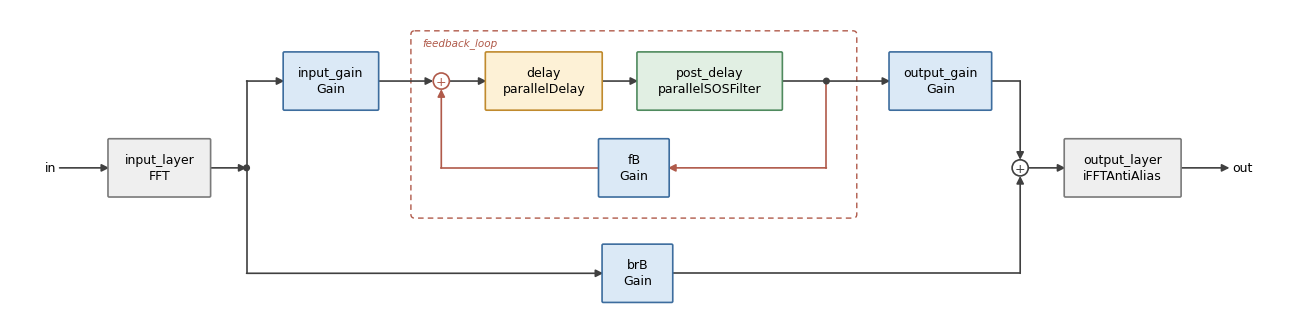

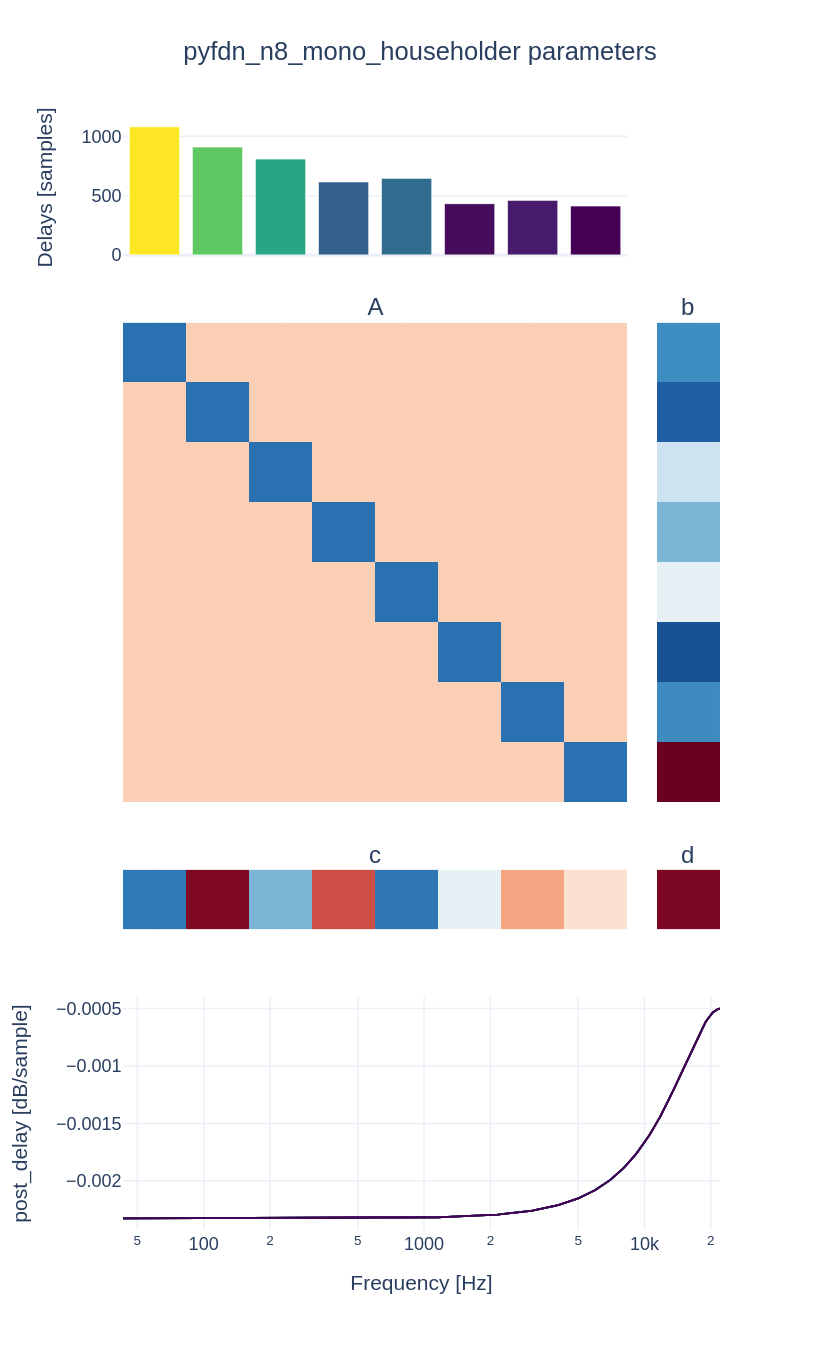

## `pyfdn_n8_mono_householder_vector`

param-spec SHA-256: 51af728a411f40cf08531f1be30398717ef560136d70b76181ad87ae8b88d8fd


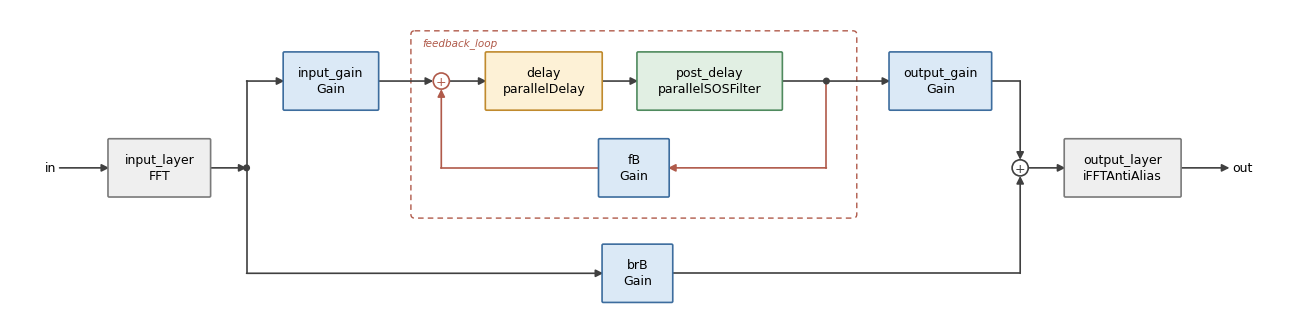

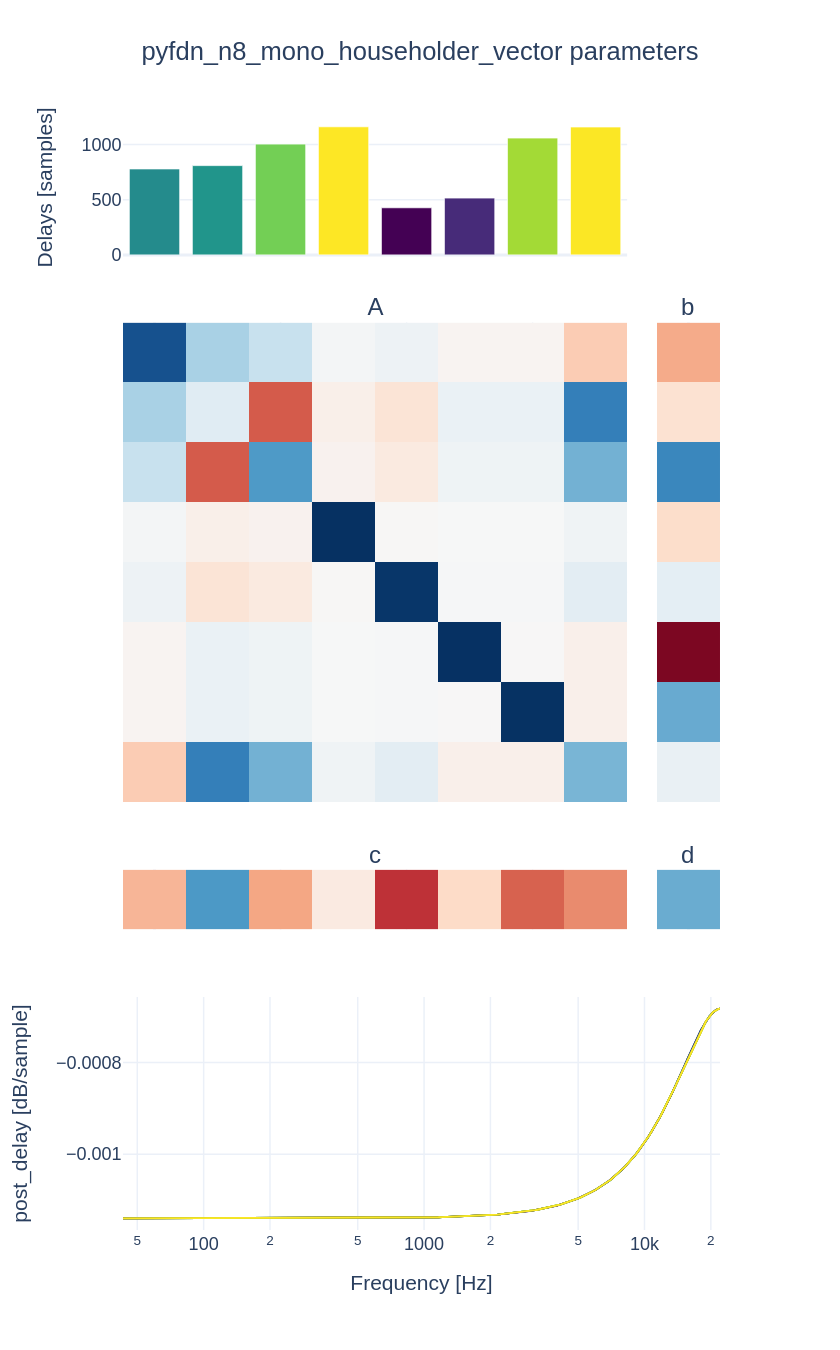

## `pyfdn_n8_mono_kronecker`

param-spec SHA-256: 66d27e7e92ba7c4b6059814647df074fd41f903f953cbb6bbc51be33263e8ee1


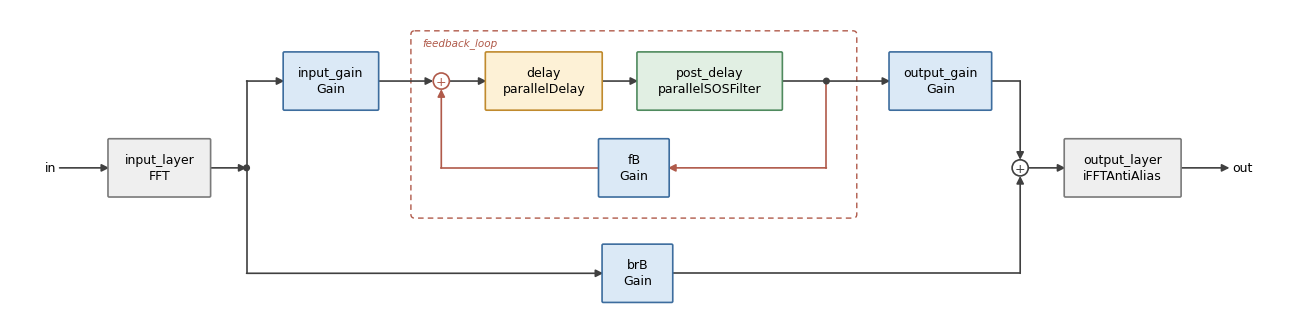

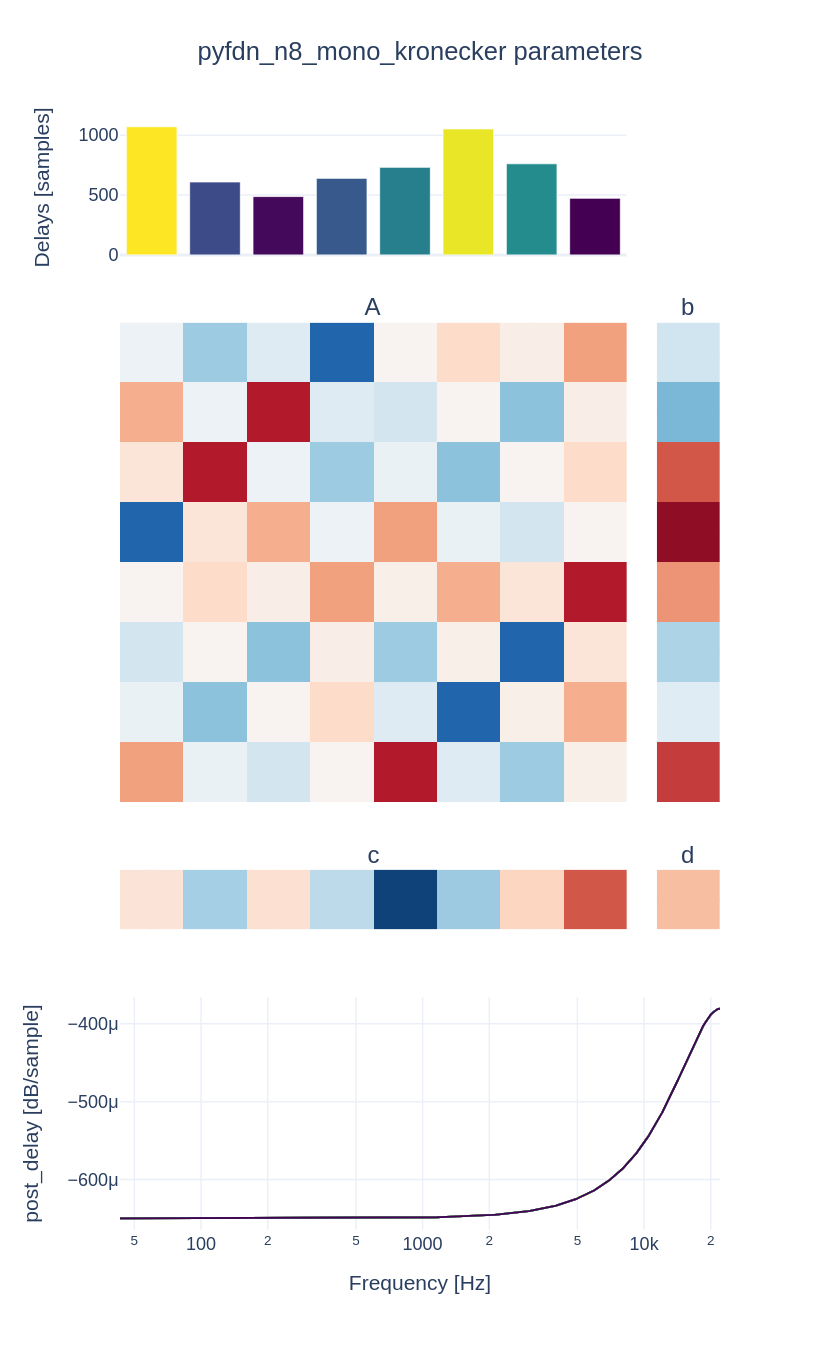

In [ ]:
for index, (name, spec) in enumerate(pyfdn_specs.items()):
    native, _ = spec.sample(np.random.default_rng(index))
    flamo_fdn = spec.to_flamo_fdn(native)
    build = flamo_fdn.build
    model = flamo_fdn.to_flamo(nfft=4096)
    display(Markdown(f"## `{name}`"))
    print(f"param-spec SHA-256: {pyfdn_param_spec_sha256(spec)}")
    plot_flamo_graph(model, name=name)
    plt.show()
    parameter_figure = plot_fdn_parameter(
        build.delays,
        build.A,
        build.B,
        build.C,
        build.D,
        post_delay_sos=build.post_delay,
        post_matrix_sos=build.post_matrix,
        post_output_sos=build.post_output,
        fs=build.fs,
        title=f"{name} parameters",
    )
    display(Image(parameter_figure.to_image(format="png", scale=1.5)))